# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier


## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [35]:
df = pd.read_csv(
    '../data/Checker Submits.csv',
    names = ["uid", "labname", "numTrials", "hour","dayofweek"],
    skiprows=1
)
df["hour"] = pd.to_datetime(df["hour"])
df["dayofweek"] = df['hour'].dt.dayofweek
df['hour'] = df['hour'].dt.hour
df

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4
...,...,...,...,...,...
1681,user_19,laba06s,9,20,3
1682,user_1,laba06s,6,20,3
1683,user_1,laba06s,7,20,3
1684,user_1,laba06s,8,20,3


In [36]:
encoder = OneHotEncoder(sparse_output=False)
cat_features = ['uid','labname']
enc_data = encoder.fit_transform(df[cat_features])
enc_cat_df = pd.DataFrame(
    enc_data,
    columns=encoder.get_feature_names_out(cat_features),
    index=df.index
)
df = df.drop(columns=['uid','labname'])
df  = pd.concat([df, enc_cat_df], axis=1)
df.head()

,numTrials,hour,dayofweek,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,...,labname_lab02,labname_lab03,labname_lab03s,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1
0,1,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,5,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [37]:
scaler = StandardScaler()
df['numTrials'] = scaler.fit_transform(df[['numTrials']])
df['hour'] = scaler.fit_transform(df[['hour']])
df.to_csv('../data/dayofweek.csv')

In [38]:
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(df.drop(columns=['dayofweek']), df['dayofweek'])
y_pred = dummy_clf.predict(df.drop(columns=['dayofweek']))
accuracy = accuracy_score(df['dayofweek'], y_pred)

print(f"Accuracy наивного классификатора: {accuracy}")


Accuracy наивного классификатора: 0.23487544483985764


## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`.
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [39]:
logreg = LogisticRegression(
    random_state=21,
    fit_intercept=False
)
X = df.drop(columns=['dayofweek'])
y = df['dayofweek']
logreg.fit(X, y)
y_pred = logreg.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy logreg: {accuracy}")

Accuracy logreg: 0.6405693950177936


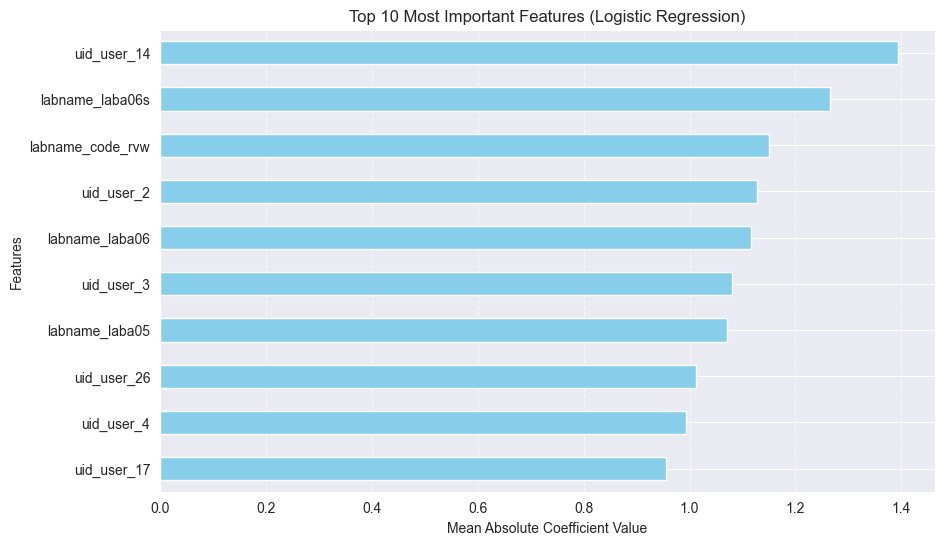

In [40]:
def plot_feature_importance(coefs, features, top_n=10):
    
    importance = np.mean(np.abs(coefs), axis=0)
    
    feat_importance = pd.Series(importance, index=features)
    top_feats = feat_importance.sort_values(ascending=True).tail(top_n)
    
    plt.figure(figsize=(10, 6))
    top_feats.plot(kind='barh', color='skyblue')
    plt.title(f'Top {top_n} Most Important Features (Logistic Regression)')
    plt.xlabel('Mean Absolute Coefficient Value')
    plt.ylabel('Features')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

plot_feature_importance(logreg.coef_, X.columns, top_n=10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`.
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [41]:
svc = SVC(kernel='linear',probability=True, random_state=21)


In [42]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
best_acc = 0
best_kernel = ''
for k in kernels:
    temp_svc = SVC(kernel=k, probability=True, random_state=21)
    temp_svc.fit(X, y)
    acc_svc = accuracy_score(y, temp_svc.predict(X))
    print(f"Для ядра {k} точность равна: {acc_svc}")
    if acc_svc > best_acc:
        best_acc = acc_svc
        best_kernel = k

print(f"best: {best_kernel} {best_acc}")

Для ядра linear точность равна: 0.702846975088968
Для ядра rbf точность равна: 0.8558718861209964
Для ядра poly точность равна: 0.8594306049822064
Для ядра sigmoid точность равна: 0.3997627520759193
best: poly 0.8594306049822064


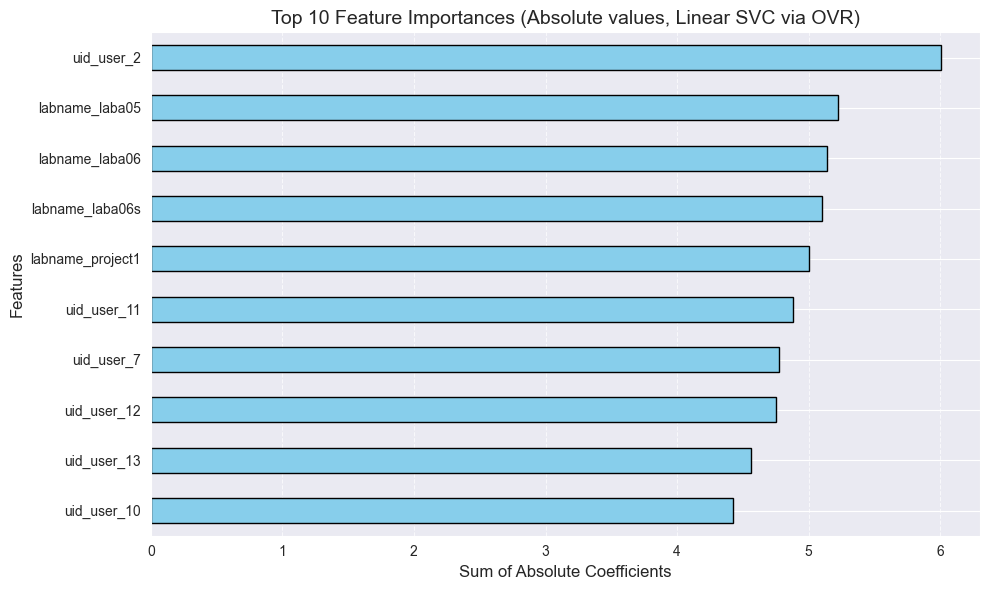

In [43]:

ovr_svc = OneVsRestClassifier(svc)
ovr_svc.fit(X, y)

importances = np.sum([np.abs(est.coef_) for est in ovr_svc.estimators_], axis=0).flatten()

feature_names = X.columns if hasattr(X, 'columns') else [f'Feature {i}' for i in range(X.shape[1])]
feat_importances = pd.Series(importances, index=feature_names)

top_10_features = feat_importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top_10_features.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Top 10 Feature Importances (Absolute values, Linear SVC via OVR)', fontsize=14)
plt.xlabel('Sum of Absolute Coefficients', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`.
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [44]:
tree = DecisionTreeClassifier(max_depth=4, random_state=21)
tree.fit(X, y)
y_pred = tree.predict(X)
accuracy = accuracy_score(y, y_pred)
print("Tree accuracy:", accuracy)

Tree accuracy: 0.5516014234875445


In [45]:

for i in range(1,21+1):
    temp_tree = DecisionTreeClassifier(max_depth=i, random_state=21)
    temp_tree.fit(X, y)
    temp_y_pred = temp_tree.predict(X)
    temp_accuracy = accuracy_score(y, temp_y_pred)
    print(f"Tree accuracy for {i} max_depth:{temp_accuracy}")

Tree accuracy for 1 max_depth:0.35765124555160144
Tree accuracy for 2 max_depth:0.4389086595492289
Tree accuracy for 3 max_depth:0.48991696322657174
Tree accuracy for 4 max_depth:0.5516014234875445
Tree accuracy for 5 max_depth:0.6109134045077106
Tree accuracy for 6 max_depth:0.6637010676156584
Tree accuracy for 7 max_depth:0.7064056939501779
Tree accuracy for 8 max_depth:0.7502965599051008
Tree accuracy for 9 max_depth:0.7846975088967971
Tree accuracy for 10 max_depth:0.8196915776986952
Tree accuracy for 11 max_depth:0.8499406880189798
Tree accuracy for 12 max_depth:0.8831553973902728
Tree accuracy for 13 max_depth:0.9104389086595492
Tree accuracy for 14 max_depth:0.9317912218268091
Tree accuracy for 15 max_depth:0.9460260972716489
Tree accuracy for 16 max_depth:0.9608540925266904
Tree accuracy for 17 max_depth:0.9709371293001187
Tree accuracy for 18 max_depth:0.9798339264531435
Tree accuracy for 19 max_depth:0.9839857651245552
Tree accuracy for 20 max_depth:0.9869513641755635
Tree ac

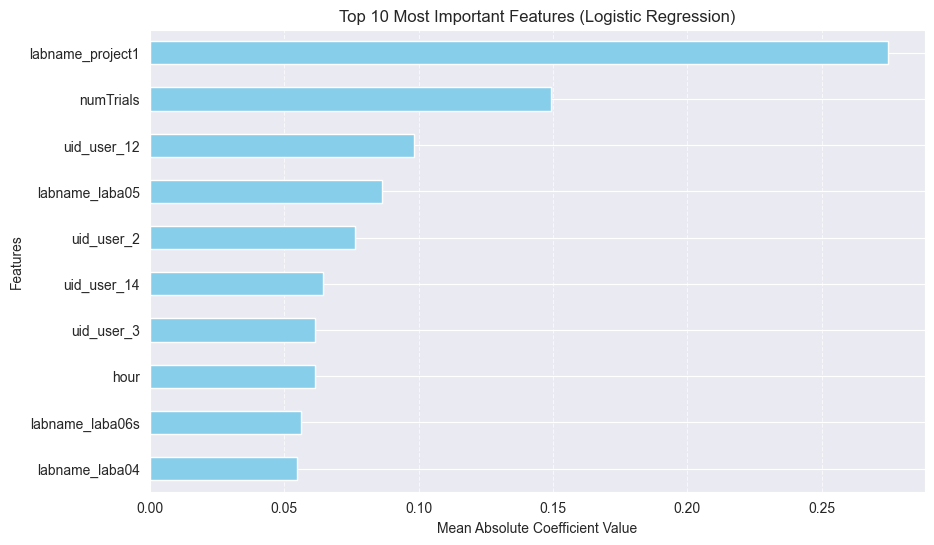

In [46]:
plot_feature_importance([tree.feature_importances_], X.columns, top_n=10)


### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`.
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [47]:
randForest = RandomForestClassifier(n_estimators=100,max_depth=25, random_state=21)

In [48]:
randForest.fit(X, y)
y_pred = randForest.predict(X)
accuracy = accuracy_score(y, y_pred)
print("Random Forest accuracy:", accuracy)

Random Forest accuracy: 1.0


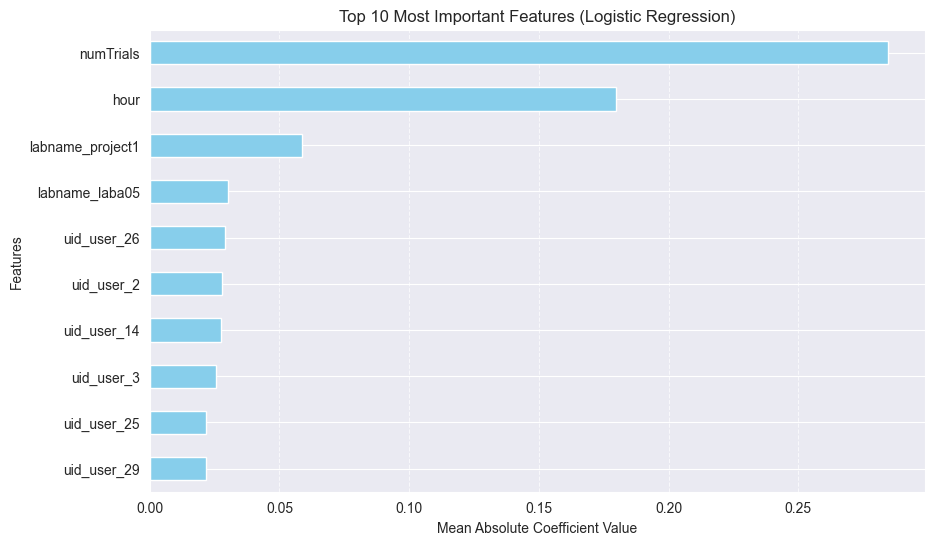

In [49]:
plot_feature_importance([randForest.feature_importances_], X.columns, top_n=10)
